# Bank Customer Churn Analysis

## Objective

The objective of this notebook is to analyze customer churn patterns and identify
the customer characteristics and behaviors associated with higher churn rates.

This analysis focuses on understanding:

- Overall customer churn
- Churn distribution across customer segments
- Demographic factors associated with churn
- Financial characteristics associated with churn
- Engagement and product usage associated with churn
- High-risk customer segments

The analysis will distinguish between **churn volume** and **churn rate** to avoid
misleading conclusions caused by differences in segment size.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/cleaned/bank_customer_churn_cleaned.csv")
data.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Dataset Shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nMissing values:")
display(data.isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Dataset Shape: (10000, 12)

Columns:
['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing values:


CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Duplicate rows: 0


## Churn KPI

In [5]:
total_customers = len(data)

churned_customers = data["Exited"].sum()

retained_customers = (data["Exited"] == 0).sum()

churn_rate = churned_customers / total_customers * 100

print("Total Customers :", f"{total_customers:,}")
print("Churned Customers:", f"{churned_customers:,}")
print("Retained Customers:", f"{retained_customers:,}")
print("Overall Churn Rate:", f"{churn_rate:.2f}%")

Total Customers : 10,000
Churned Customers: 2,037
Retained Customers: 7,963
Overall Churn Rate: 20.37%


## Churn Distribution

In [7]:
churn_distribution = data["Exited"].value_counts().sort_index()
churn_distribution.index = ["Retained", "Churned"]

print(churn_distribution)

Retained    7963
Churned     2037
Name: count, dtype: int64


In [8]:
churn_percentage = (
    data["Exited"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

churn_percentage.index = ["Retained", "Churned"]

display(churn_percentage)

Retained    79.63
Churned     20.37
Name: proportion, dtype: float64

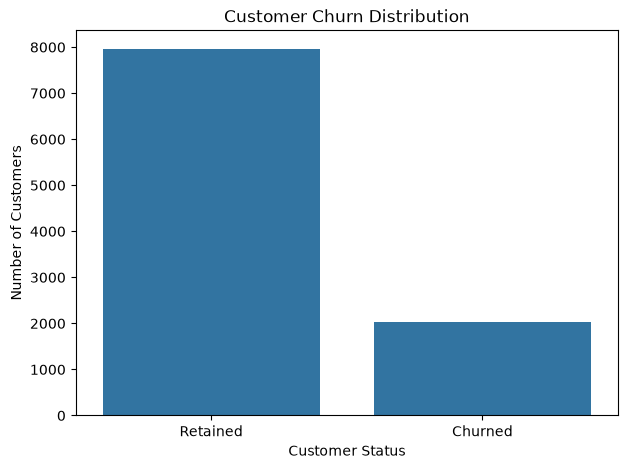

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Exited"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Retained", "Churned"])

plt.show()

## Churn by Geography

In [10]:
geo_churn = (
    data.groupby("Geography")
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

geo_churn["Churn_Rate"] = (
    geo_churn["Churned_Customers"]
    / geo_churn["Total_Customers"]
    * 100
)

geo_churn = geo_churn.sort_values(
    "Churn_Rate",
    ascending=False
)

display(geo_churn)

,Total_Customers,Churned_Customers,Churn_Rate
Geography,,,
Germany,2509,814,32.443204
Spain,2477,413,16.673395
France,5014,810,16.154767


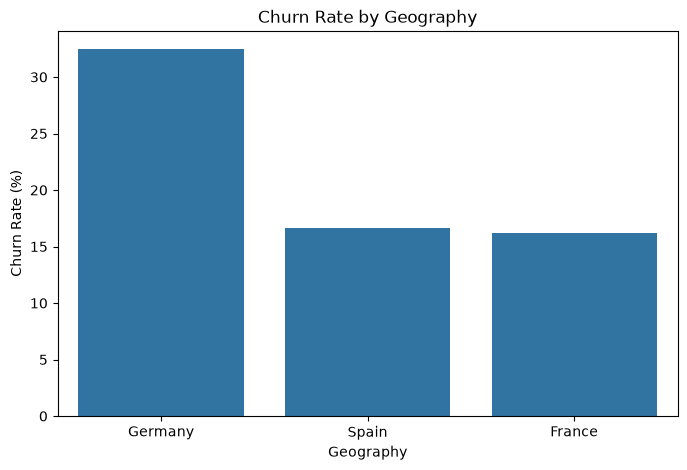

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=geo_churn.reset_index(),
    x="Geography",
    y="Churn_Rate"
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

plt.show()

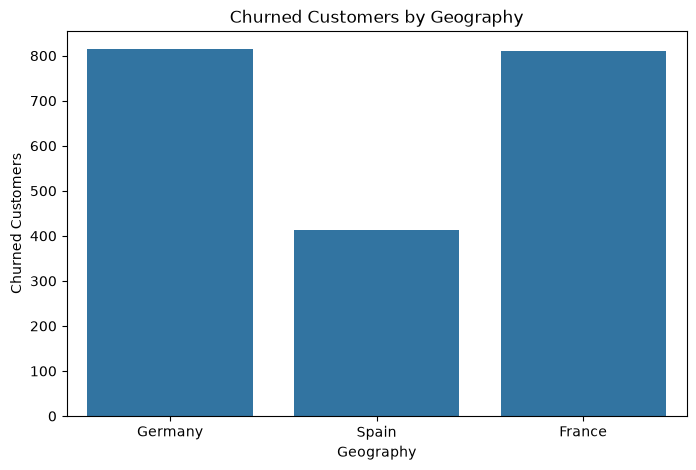

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=geo_churn.reset_index(),
    x="Geography",
    y="Churned_Customers"
)

plt.title("Churned Customers by Geography")
plt.xlabel("Geography")
plt.ylabel("Churned Customers")

plt.show()

## Churn by Gender

In [13]:
gender_churn = (
    data.groupby("Gender")
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

gender_churn["Churn_Rate"] = (
    gender_churn["Churned_Customers"]
    / gender_churn["Total_Customers"]
    * 100
)

display(gender_churn.sort_values("Churn_Rate", ascending=False))

,Total_Customers,Churned_Customers,Churn_Rate
Gender,,,
Female,4543,1139,25.071539
Male,5457,898,16.455928


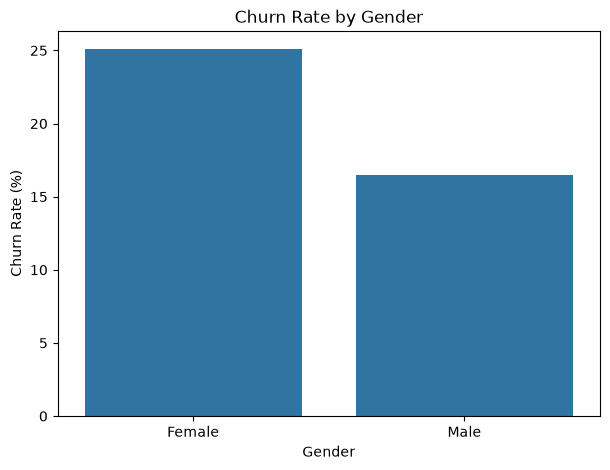

In [14]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_churn.reset_index(),
    x="Gender",
    y="Churn_Rate"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churn by Age

In [15]:
data["Age_Group"] = pd.cut(
    data["Age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

In [17]:
age_churn = (
    data.groupby("Age_Group", observed=True)
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

age_churn["Churn_Rate"] = (
    age_churn["Churned_Customers"]
    / age_churn["Total_Customers"]
    * 100
)

display(age_churn)

,Total_Customers,Churned_Customers,Churn_Rate
Age_Group,,,
18-25,611,46,7.528642
26-35,3542,301,8.498024
36-45,3736,733,19.619914
46-55,1311,663,50.572082
56-65,536,259,48.320896
66+,264,35,13.257576


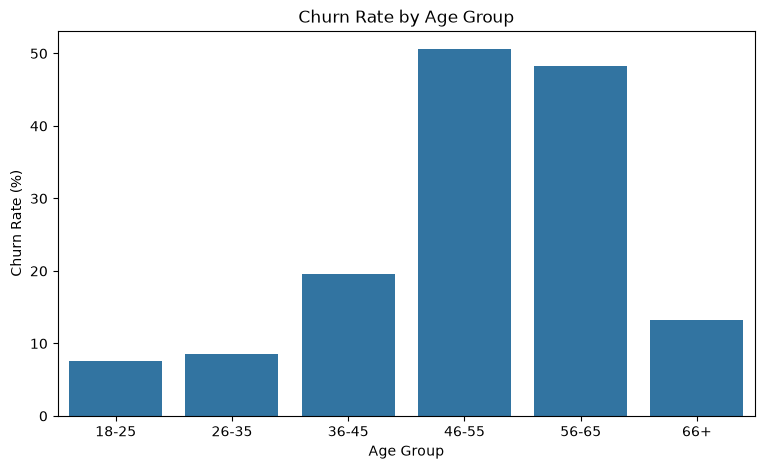

In [18]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_churn.reset_index(),
    x="Age_Group",
    y="Churn_Rate"
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churn by Credit Score

In [19]:
data["Credit_Score_Group"] = pd.cut(
    data["CreditScore"],
    bins=[300, 500, 600, 700, 800, 900],
    labels=[
        "300-499",
        "500-599",
        "600-699",
        "700-799",
        "800+"
    ]
)

In [20]:
credit_churn = (
    data.groupby("Credit_Score_Group", observed=True)
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

credit_churn["Churn_Rate"] = (
    credit_churn["Churned_Customers"]
    / credit_churn["Total_Customers"]
    * 100
)

display(credit_churn)

,Total_Customers,Churned_Customers,Churn_Rate
Credit_Score_Group,,,
300-499,643,152,23.639191
500-599,2423,513,21.172101
600-699,3818,753,19.722368
700-799,2471,492,19.910967
800+,645,127,19.689922


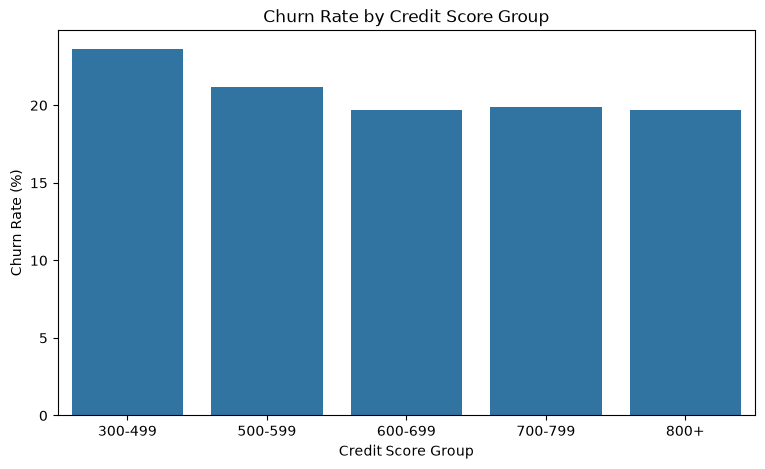

In [21]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=credit_churn.reset_index(),
    x="Credit_Score_Group",
    y="Churn_Rate"
)

plt.title("Churn Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churn by Tenure

In [22]:
tenure_churn = (
    data.groupby("Tenure")
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

tenure_churn["Churn_Rate"] = (
    tenure_churn["Churned_Customers"]
    / tenure_churn["Total_Customers"]
    * 100
)

display(tenure_churn)

,Total_Customers,Churned_Customers,Churn_Rate
Tenure,,,
0,413,95,23.002421
1,1035,232,22.415459
2,1048,201,19.179389
3,1009,213,21.110010
4,989,203,20.525784
5,1012,209,20.652174
6,967,196,20.268873
7,1028,177,17.217899
8,1025,197,19.219512


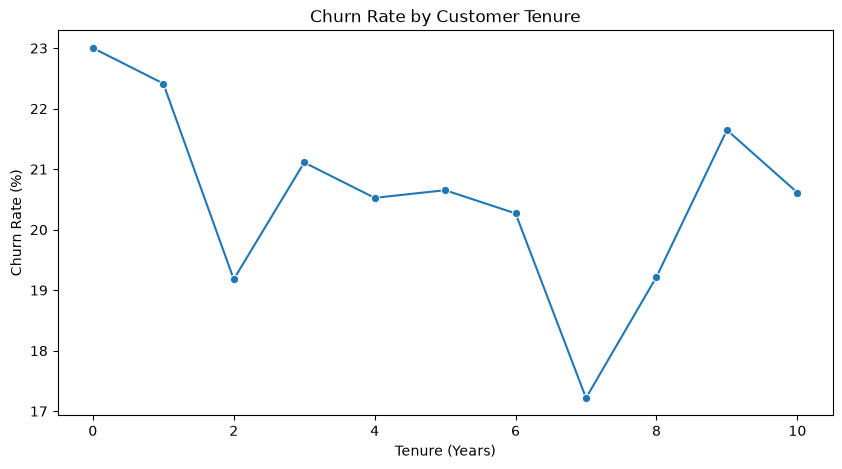

In [23]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=tenure_churn.reset_index(),
    x="Tenure",
    y="Churn_Rate",
    marker="o"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churn by Balance

In [24]:
data["Balance_Group"] = pd.cut(
    data["Balance"],
    bins=[-1, 50000, 100000, 150000, 200000, np.inf],
    labels=[
        "0-50K",
        "50K-100K",
        "100K-150K",
        "150K-200K",
        "200K+"
    ]
)

In [25]:
balance_churn = (
    data.groupby("Balance_Group", observed=True)
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

balance_churn["Churn_Rate"] = (
    balance_churn["Churned_Customers"]
    / balance_churn["Total_Customers"]
    * 100
)

display(balance_churn)

,Total_Customers,Churned_Customers,Churn_Rate
Balance_Group,,,
0-50K,3692,526,14.247021
50K-100K,1509,300,19.880716
100K-150K,3830,987,25.770235
150K-200K,935,205,21.925134
200K+,34,19,55.882353


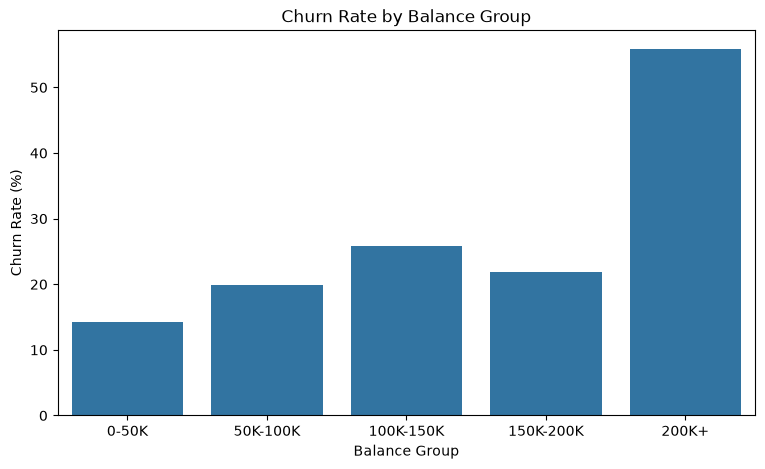

In [26]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=balance_churn.reset_index(),
    x="Balance_Group",
    y="Churn_Rate"
)

plt.title("Churn Rate by Balance Group")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churn by Number of Products

In [27]:
product_churn = (
    data.groupby("NumOfProducts")
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

product_churn["Churn_Rate"] = (
    product_churn["Churned_Customers"]
    / product_churn["Total_Customers"]
    * 100
)

display(product_churn)

,Total_Customers,Churned_Customers,Churn_Rate
NumOfProducts,,,
1,5084,1409,27.714398
2,4590,348,7.581699
3,266,220,82.706767
4,60,60,100.000000


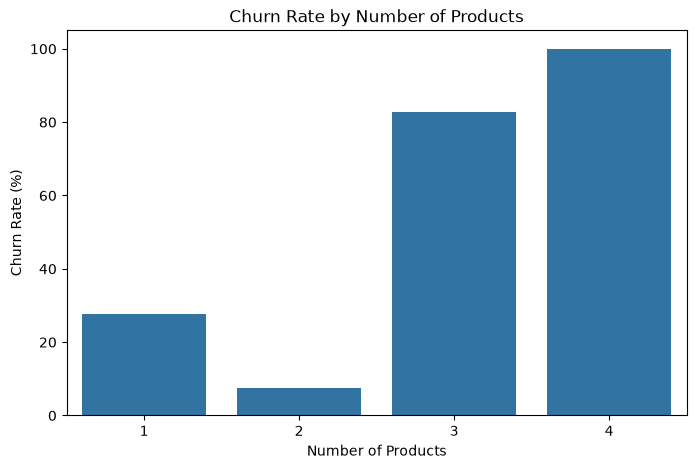

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_churn.reset_index(),
    x="NumOfProducts",
    y="Churn_Rate"
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churn by Credit Card Ownership

In [29]:
card_churn = (
    data.groupby("HasCrCard")
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

card_churn["Churn_Rate"] = (
    card_churn["Churned_Customers"]
    / card_churn["Total_Customers"]
    * 100
)

card_churn.index = ["No Credit Card", "Has Credit Card"]

display(card_churn)

,Total_Customers,Churned_Customers,Churn_Rate
No Credit Card,2945,613,20.814941
Has Credit Card,7055,1424,20.184266


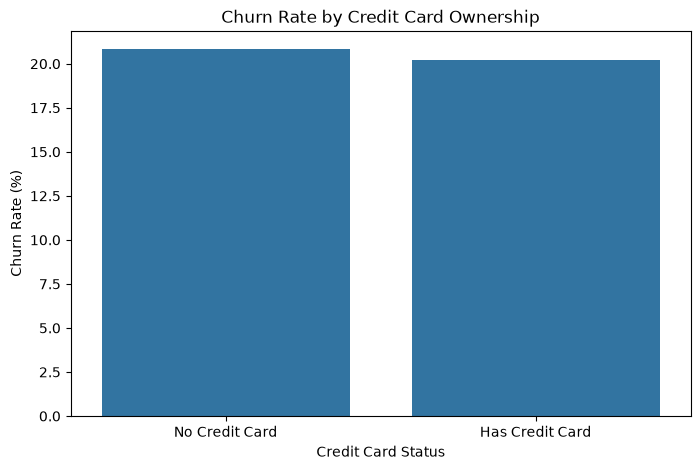

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=card_churn.index,
    y=card_churn["Churn_Rate"]
)

plt.title("Churn Rate by Credit Card Ownership")
plt.xlabel("Credit Card Status")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churn by Active Membership

In [31]:
active_churn = (
    data.groupby("IsActiveMember")
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

active_churn["Churn_Rate"] = (
    active_churn["Churned_Customers"]
    / active_churn["Total_Customers"]
    * 100
)

active_churn.index = ["Inactive Member", "Active Member"]

display(active_churn)

,Total_Customers,Churned_Customers,Churn_Rate
Inactive Member,4849,1302,26.850897
Active Member,5151,735,14.269074


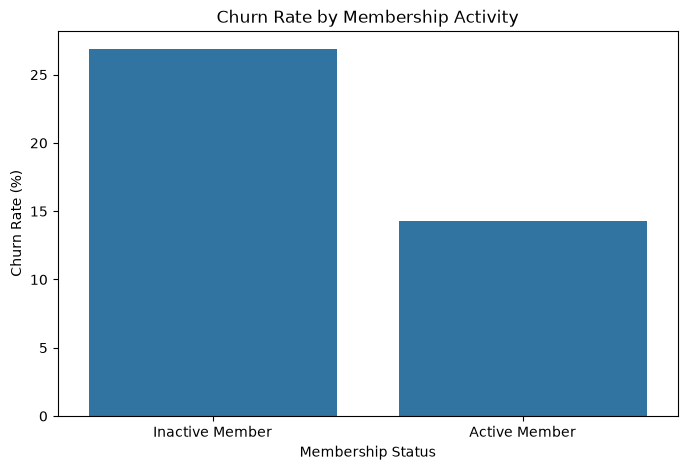

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=active_churn.index,
    y=active_churn["Churn_Rate"]
)

plt.title("Churn Rate by Membership Activity")
plt.xlabel("Membership Status")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churn by Estimated Salary

In [33]:
data["Salary_Group"] = pd.cut(
    data["EstimatedSalary"],
    bins=[-1, 50000, 100000, 150000, 200000, np.inf],
    labels=[
        "0-50K",
        "50K-100K",
        "100K-150K",
        "150K-200K",
        "200K+"
    ]
)

In [34]:
salary_churn = (
    data.groupby("Salary_Group", observed=True)
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

salary_churn["Churn_Rate"] = (
    salary_churn["Churned_Customers"]
    / salary_churn["Total_Customers"]
    * 100
)

display(salary_churn)

,Total_Customers,Churned_Customers,Churn_Rate
Salary_Group,,,
0-50K,2453,489,19.934774
50K-100K,2537,504,19.865983
100K-150K,2555,517,20.234834
150K-200K,2455,527,21.466395


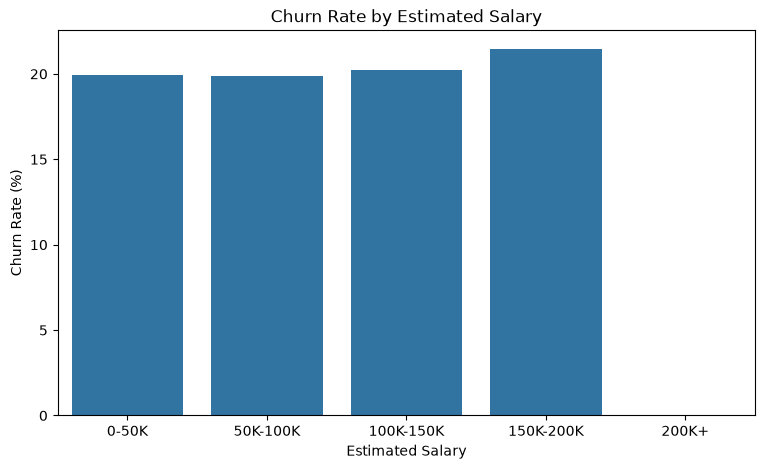

In [35]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=salary_churn.reset_index(),
    x="Salary_Group",
    y="Churn_Rate"
)

plt.title("Churn Rate by Estimated Salary")
plt.xlabel("Estimated Salary")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churned vs Retained Customer Profile

In [36]:
customer_profile = (
    data.groupby("Exited")
    .agg(
        Avg_CreditScore=("CreditScore", "mean"),
        Avg_Age=("Age", "mean"),
        Avg_Tenure=("Tenure", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean"),
        Avg_Salary=("EstimatedSalary", "mean")
    )
)

customer_profile.index = ["Retained", "Churned"]

display(customer_profile)

,Avg_CreditScore,Avg_Age,Avg_Tenure,Avg_Balance,Avg_Products,Avg_Salary
Retained,651.853196,37.408389,5.033279,72745.296779,1.544267,99738.391772
Churned,645.351497,44.837997,4.932744,91108.539337,1.475209,101465.677531


## Numerical Variable Visual Comparison

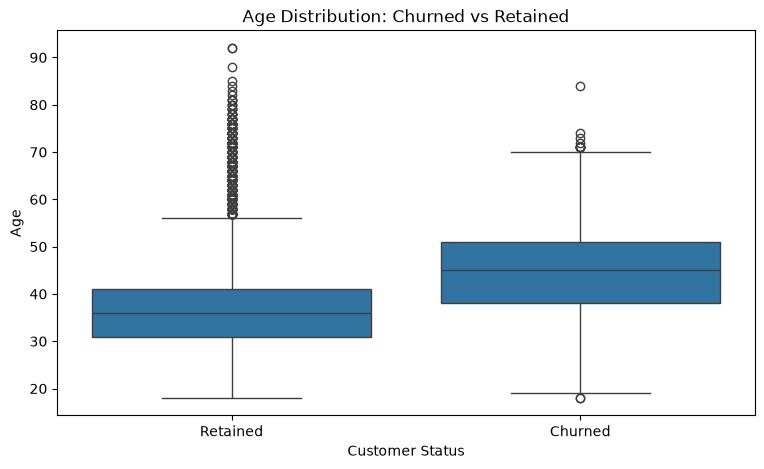

In [37]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=data,
    x="Exited",
    y="Age"
)

plt.title("Age Distribution: Churned vs Retained")
plt.xlabel("Customer Status")
plt.ylabel("Age")
plt.xticks([0, 1], ["Retained", "Churned"])

plt.show()

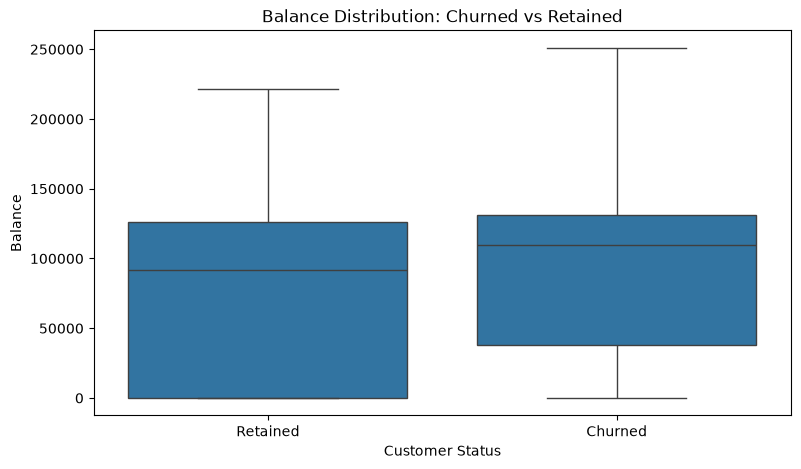

In [38]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=data,
    x="Exited",
    y="Balance"
)

plt.title("Balance Distribution: Churned vs Retained")
plt.xlabel("Customer Status")
plt.ylabel("Balance")
plt.xticks([0, 1], ["Retained", "Churned"])

plt.show()

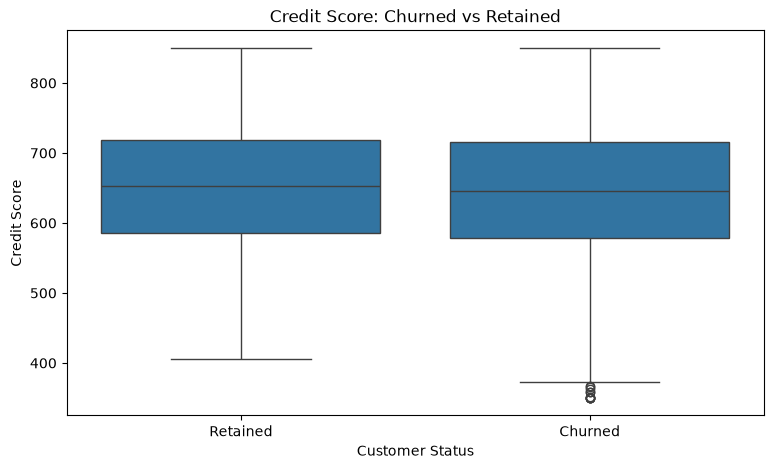

In [39]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=data,
    x="Exited",
    y="CreditScore"
)

plt.title("Credit Score: Churned vs Retained")
plt.xlabel("Customer Status")
plt.ylabel("Credit Score")
plt.xticks([0, 1], ["Retained", "Churned"])

plt.show()

## Churn Correlation Analysis

In [40]:
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited"
]

correlation = data[numeric_columns].corr()["Exited"].sort_values(
    ascending=False
)

display(correlation)

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64

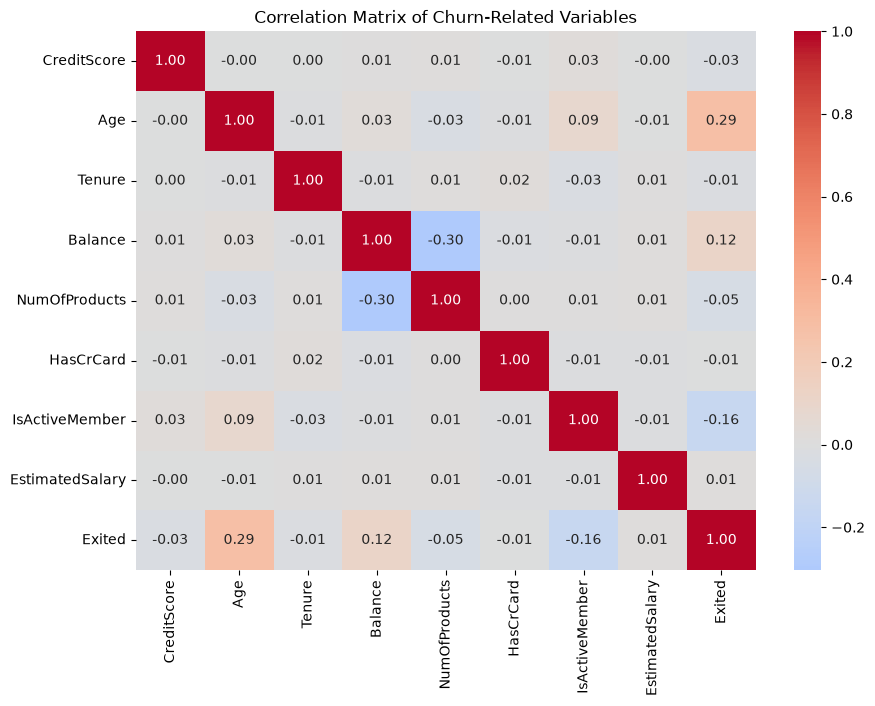

In [41]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    data[numeric_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Churn-Related Variables")

plt.show()

**Correlation measures association between variables; it does not establish causation.**

## Identify High-Risk Segments

**Inactive members**

In [42]:
inactive_customers = data[data["IsActiveMember"] == 0]

inactive_churn_rate = inactive_customers["Exited"].mean() * 100

print(
    f"Churn rate among inactive members: {inactive_churn_rate:.2f}%"
)

Churn rate among inactive members: 26.85%


**Customers with 1 product**

In [43]:
one_product = data[data["NumOfProducts"] == 1]

print(
    f"Churn rate among customers with 1 product: "
    f"{one_product['Exited'].mean() * 100:.2f}%"
)

Churn rate among customers with 1 product: 27.71%


**Customers with 2 products**

In [44]:
two_products = data[data["NumOfProducts"] == 2]

print(
    f"Churn rate among customers with 2 products: "
    f"{two_products['Exited'].mean() * 100:.2f}%"
)

Churn rate among customers with 2 products: 7.58%


## Combined Risk Segment Analysis

**Age & Active Member**

In [45]:
age_activity_churn = (
    data.groupby(["Age_Group", "IsActiveMember"], observed=True)
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

age_activity_churn["Churn_Rate"] = (
    age_activity_churn["Churned_Customers"]
    / age_activity_churn["Total_Customers"]
    * 100
)

display(
    age_activity_churn
    .sort_values("Churn_Rate", ascending=False)
)

Total_Customers  Churned_Customers  Churn_Rate
Age_Group IsActiveMember                                                
56-65     0                           179                168   93.854749
46-55     0                           665                423   63.609023
66+       0                            32                 20   62.500000
46-55     1                           646                240   37.151703
56-65     1                           357                 91   25.490196
36-45     0                          1945                471   24.215938
          1                          1791                262   14.628699
18-25     0                           288                 32   11.111111
26-35     0                          1740                188   10.804598
66+       1                           232                 15    6.465517
26-35     1                          1802                113    6.270810
18-25     1                           323                 14    4.334365

**Geography & Active Member**

In [46]:
geo_activity_churn = (
    data.groupby(["Geography", "IsActiveMember"])
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

geo_activity_churn["Churn_Rate"] = (
    geo_activity_churn["Churned_Customers"]
    / geo_activity_churn["Total_Customers"]
    * 100
)

display(
    geo_activity_churn
    .sort_values("Churn_Rate", ascending=False)
)

Total_Customers  Churned_Customers  Churn_Rate
Geography IsActiveMember                                                
Germany   0                          1261                518   41.078509
          1                          1248                296   23.717949
Spain     0                          1165                272   23.347639
France    0                          2423                512   21.130830
          1                          2591                298   11.501351
Spain     1                          1312                141   10.746951

**Age & Number of Products**

In [47]:
age_product_churn = (
    data.groupby(["Age_Group", "NumOfProducts"], observed=True)
    .agg(
        Total_Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum")
    )
)

age_product_churn["Churn_Rate"] = (
    age_product_churn["Churned_Customers"]
    / age_product_churn["Total_Customers"]
    * 100
)

display(
    age_product_churn
    .sort_values("Churn_Rate", ascending=False)
)

Total_Customers  Churned_Customers  Churn_Rate
Age_Group NumOfProducts                                                
26-35     4                            8                  8  100.000000
46-55     4                           21                 21  100.000000
66+       4                            1                  1  100.000000
56-65     4                            7                  7  100.000000
          3                           28                 28  100.000000
36-45     4                           23                 23  100.000000
46-55     3                           64                 63   98.437500
36-45     3                          107                 90   84.112150
46-55     1                          797                488   61.229611
18-25     3                           10                  6   60.000000
26-35     3                           50                 30   60.000000
56-65     1                          312                171   54.807692
66+       3                            7                  3   42.857143
56-65     2                          189                 53   28.042328
36-45     1                         1858                484   26.049516
46-55     2                          429                 91   21.212121
66+       1                          135                 22   16.296296
26-35     1                         1697                216   12.728344
18-25     1                          285                 28    9.824561
36-45     2                         1748                136    7.780320
66+       2                          121                  9    7.438017
18-25     2                          316                 12    3.797468
26-35     2                         1787                 47    2.630106

## Churn Risk Summary

In [48]:
segment_results = []

segment_columns = [
    "Geography",
    "Gender",
    "Age_Group",
    "Credit_Score_Group",
    "Tenure",
    "Balance_Group",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "Salary_Group"
]

for column in segment_columns:

    temp = (
        data.groupby(column, observed=True)
        .agg(
            Total_Customers=("CustomerId", "count"),
            Churned_Customers=("Exited", "sum")
        )
        .reset_index()
    )

    temp["Churn_Rate"] = (
        temp["Churned_Customers"]
        / temp["Total_Customers"]
        * 100
    )

    temp["Segment"] = column

    segment_results.append(temp)

risk_summary = pd.concat(segment_results, ignore_index=True)

risk_summary = risk_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

display(risk_summary.head(20))


# One problem with churn rates is that very small groups can produce misleadingly high rates.
# For example:2 customers → 2 churned → 100% churn That's statistically weak.
# So we'll only consider segments with a reasonable customer base.

,Geography,Total_Customers,Churned_Customers,Churn_Rate,Segment,Gender,Age_Group,Credit_Score_Group,Tenure,Balance_Group,NumOfProducts,HasCrCard,IsActiveMember,Salary_Group
35,NaN,60,60,100.000000,NumOfProducts,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
34,NaN,266,220,82.706767,NumOfProducts,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN
31,NaN,34,19,55.882353,Balance_Group,NaN,NaN,NaN,NaN,200K+,NaN,NaN,NaN,NaN
8,NaN,1311,663,50.572082,Age_Group,NaN,46-55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,536,259,48.320896,Age_Group,NaN,56-65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Germany,2509,814,32.443204,Geography,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,NaN,5084,1409,27.714398,NumOfProducts,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
38,NaN,4849,1302,26.850897,IsActiveMember,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
29,NaN,3830,987,25.770235,Balance_Group,NaN,NaN,NaN,NaN,100K-150K,NaN,NaN,NaN,NaN
3,NaN,4543,1139,25.071539,Gender,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**A minimum segment size of 100 customers is used to reduce the influence of unstable churn rates from very small groups.**

In [49]:
risk_summary_reliable = risk_summary[
    risk_summary["Total_Customers"] >= 100
].sort_values(
    "Churn_Rate",
    ascending=False
)

display(risk_summary_reliable.head(20))

,Geography,Total_Customers,Churned_Customers,Churn_Rate,Segment,Gender,Age_Group,Credit_Score_Group,Tenure,Balance_Group,NumOfProducts,HasCrCard,IsActiveMember,Salary_Group
34,NaN,266,220,82.706767,NumOfProducts,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN
8,NaN,1311,663,50.572082,Age_Group,NaN,46-55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,536,259,48.320896,Age_Group,NaN,56-65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Germany,2509,814,32.443204,Geography,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,NaN,5084,1409,27.714398,NumOfProducts,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
38,NaN,4849,1302,26.850897,IsActiveMember,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
29,NaN,3830,987,25.770235,Balance_Group,NaN,NaN,NaN,NaN,100K-150K,NaN,NaN,NaN,NaN
3,NaN,4543,1139,25.071539,Gender,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,NaN,643,152,23.639191,Credit_Score_Group,NaN,NaN,300-499,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,413,95,23.002421,Tenure,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN


## Churn Rate vs Overall Churn

In [50]:
high_risk_segments = risk_summary_reliable[
    risk_summary_reliable["Churn_Rate"] > churn_rate
]

display(
    high_risk_segments.head(20)
)

,Geography,Total_Customers,Churned_Customers,Churn_Rate,Segment,Gender,Age_Group,Credit_Score_Group,Tenure,Balance_Group,NumOfProducts,HasCrCard,IsActiveMember,Salary_Group
34,NaN,266,220,82.706767,NumOfProducts,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN
8,NaN,1311,663,50.572082,Age_Group,NaN,46-55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,536,259,48.320896,Age_Group,NaN,56-65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Germany,2509,814,32.443204,Geography,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,NaN,5084,1409,27.714398,NumOfProducts,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
38,NaN,4849,1302,26.850897,IsActiveMember,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
29,NaN,3830,987,25.770235,Balance_Group,NaN,NaN,NaN,NaN,100K-150K,NaN,NaN,NaN,NaN
3,NaN,4543,1139,25.071539,Gender,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,NaN,643,152,23.639191,Credit_Score_Group,NaN,NaN,300-499,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,413,95,23.002421,Tenure,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN


# Key Business Insights

Based on the churn analysis, the following patterns should be evaluated:

1. **Overall churn**
   - The bank experiences a meaningful level of customer attrition.
   - The overall churn rate provides the benchmark against which all customer
     segments are compared.

2. **Geographical differences**
   - Germany has the highest churn rate among the three countries, making it a priority market for retention analysis.
   - Certain markets may require targeted retention strategies rather than
     a single global approach.

3. **Age**
   - Churn behavior differs across age groups.
   - Higher-risk age segments should be investigated for differences in
     customer needs, engagement, and product usage.

4. **Customer engagement**
   - Active membership status should be closely monitored because customer
     engagement can be strongly associated with retention.
   - Inactive customers show substantially higher churn than active customers, highlighting engagement as a major retention signal.

5. **Number of products**
   - Product holdings show differences in churn behavior.
   - Customers with certain product counts show materially different churn rates, indicating that product relationship is an
     important segmentation dimension.

6. **Financial characteristics**
   - Balance and credit-score groups may show different churn patterns.
   - These variables should be interpreted as associations rather than causal
     drivers.

7. **High-risk segments**
   - Combining multiple characteristics can reveal more specific customer
     segments with elevated churn rates.
   - Retention campaigns should prioritize high-risk segments with sufficiently
     large customer populations.

8. **Business implication**
   - The bank should focus retention efforts on identifiable high-risk
     customer segments rather than applying the same intervention to every
     customer.

# Conclusion

This analysis examined customer churn across demographic, financial,
engagement, and product-related characteristics.

The analysis shows that customer churn is not evenly distributed across the
customer base. Certain customer segments exhibit substantially higher churn
rates than the overall population.

The most important factors identified through exploratory analysis should be
used to guide targeted retention strategies and can serve as inputs for a
future predictive churn model.

The findings from this notebook provide the analytical foundation for
understanding **who is most likely to churn and which customer segments
require greater retention attention**.